### CONJUNTO DE DADOS DE PREÇOS GLOBAIS DE CELULARES<br>
#### Essa base de dados é um conjunto de dados fictício.<br>
#### Está disponível em um arquivo CSV e pode ser encontrada no Kaggle.com

In [1]:
# Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt


In [38]:
# Importando a base de dados 
base_dados = 'Global_Mobile_Prices_2025_Extended.csv'

df = pd.read_csv(base_dados, sep=';')


In [39]:
df.head() # Visualizando as 5 primeiras linhas da nossa base

,brand,model,price_usd,ram_gb,storage_gb,camera_mp,battery_mah,display_size_inch,charging_watt,5g_support,os,processor,rating,release_month,year
0,Oppo,A98 111,855,16,128,108,6000,6.6,33,Yes,Android,Helio G99,3.8,February,2025
1,Realme,11 Pro+ 843,618,6,128,64,4500,6.9,100,Yes,Android,Tensor G4,4.4,August,2025
2,Xiaomi,Redmi Note 14 Pro 461,258,16,64,64,4000,6.8,44,Yes,Android,A18 Pro,4.1,March,2025
3,Vivo,V29e 744,837,6,512,48,4500,6.0,65,Yes,Android,Exynos 2400,4.1,August,2025
4,Apple,iPhone 16 Pro Max 927,335,12,128,200,5000,6.9,100,Yes,iOS,Dimensity 9300,3.5,February,2025


In [53]:
df.tail() # Visualizando as 5 últimas linhas

,brand,model,price_usd,ram_gb,storage_gb,camera_mp,battery_mah,display_size_inch,charging_watt,5g_support,os,processor,rating,release_month,year
995,Google,Pixel 7a 2,961,8,256,12,4000,5.9,44,Yes,Android,Helio G99,4.0,November,2025
996,OnePlus,OnePlus 13R 423,158,16,64,64,5500,5.6,65,Yes,Android,Dimensity 9300,3.5,November,2025
997,Xiaomi,Poco X6 Pro 796,1164,6,128,200,4500,5.7,120,No,Android,Helio G99,4.8,January,2025
998,Realme,Narzo 70 809,895,8,64,48,5000,7.0,65,No,Android,A18 Pro,4.6,August,2025
999,Xiaomi,Mi 13 Ultra 429,458,16,512,64,4500,5.8,18,No,Android,A18 Pro,3.9,July,2025


### Exploração dos dados

In [40]:
df.shape # Visualizando a quantidade de linhas(registros) e colunas(campos)

(1000, 15)

In [41]:
df.columns # Conhecendo as colunas da nossa base

Index(['brand', 'model', 'price_usd', 'ram_gb', 'storage_gb', 'camera_mp',
       'battery_mah', 'display_size_inch', 'charging_watt', '5g_support', 'os',
       'processor', 'rating', 'release_month', 'year'],
      dtype='object')

In [55]:
valores_duplicados = df.duplicated().sum() # Verificando valores duplicados presentes na base
print(f'Quantidade de duplicatas: \n {valores_duplicados}')

Quantidade de duplicatas: 
 0


In [43]:
df.isnull().sum() # Verificação de dados faltantes(NaN)


brand                0
model                0
price_usd            0
ram_gb               0
storage_gb           0
camera_mp            0
battery_mah          0
display_size_inch    0
charging_watt        0
5g_support           0
os                   0
processor            0
rating               0
release_month        0
year                 0
dtype: int64

In [56]:
df.info() # Obtendo um resumo geral da base antes de partirmos para as análises gerais

#Check list da base:

# Tipos de dados corretos
# Ausência de dados Nulos
# Sem valores duplicados



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              1000 non-null   object 
 1   model              1000 non-null   object 
 2   price_usd          1000 non-null   int64  
 3   ram_gb             1000 non-null   int64  
 4   storage_gb         1000 non-null   int64  
 5   camera_mp          1000 non-null   int64  
 6   battery_mah        1000 non-null   int64  
 7   display_size_inch  1000 non-null   float64
 8   charging_watt      1000 non-null   int64  
 9   5g_support         1000 non-null   object 
 10  os                 1000 non-null   object 
 11  processor          1000 non-null   object 
 12  rating             1000 non-null   float64
 13  release_month      1000 non-null   object 
 14  year               1000 non-null   int64  
dtypes: float64(2), int64(7), object(6)
memory usage: 117.3+ KB


### PARTINDO PARA ALGUMAS PERGUNTAS DE CASO

### Quais são as diferentes tipos de marcas que temos no nosso conjunto de dados e quantas vezes cada marca apareceu? 

In [10]:
contagem_dos_celulares_p_marca = df['brand'].value_counts().sort_values(ascending=False)
print(contagem_dos_celulares_p_marca)

brand
Vivo       122
Google     116
OnePlus    116
Xiaomi     114
Oppo       110
Apple      107
Realme     105
Infinix    105
Samsung    105
Name: count, dtype: int64


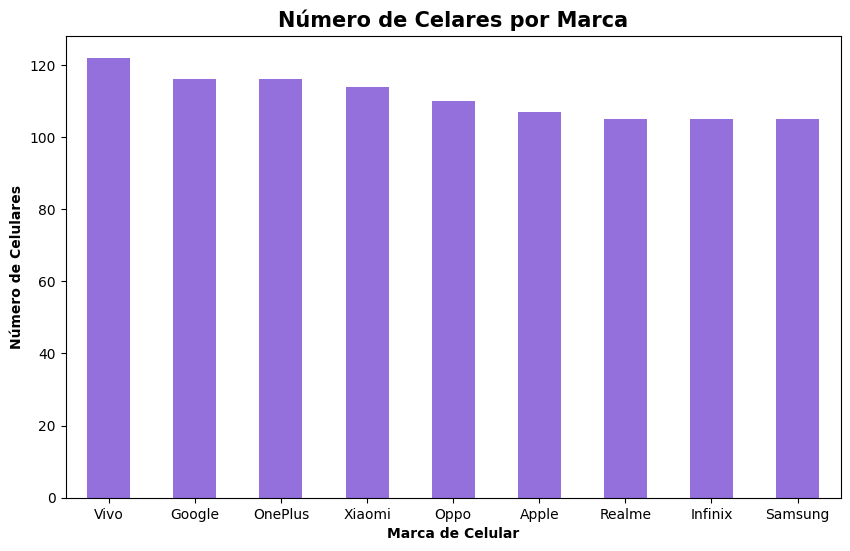

In [12]:
plt.figure(figsize=(10, 6))

contagem_dos_celulares_p_marca.plot(kind='bar', color='mediumpurple')

plt.title("Número de Celares por Marca", fontsize=15, fontweight='bold')
plt.xlabel("Marca de Celular", fontsize=10, fontweight='bold')
plt.ylabel("Número de Celulares", fontsize=10, fontweight='bold')
plt.xticks(rotation=0, ha='center')
plt.show()

### Quais foram os 3 modelos e marcas de celulares mais bem avaliados?

In [57]:
# Modelos

modelos_avaliados =(
     df.groupby('model')['rating']
     .mean()
     .reset_index()
     .rename(columns={'model':'Modelo', 'rating':'Avaliação'})
     .sort_values(by='Avaliação', ascending=False)
)

print(f'Os 3 modelos mais bem avaliados são:\n \n{modelos_avaliados.head(3)}\n')


# Marcas

marcas_avaliadas =(
     df.groupby('brand')['rating']
     .mean()
     .round(1)
     .reset_index()
     .rename(columns={'brand':'Marca', 'rating':'Avaliação'})
     .sort_values(by='Avaliação', ascending=False)
)

print(f'E as 3 marcas mais avaliadas são:\n \n{marcas_avaliadas.head(3)}')



Os 3 modelos mais bem avaliados são:
 
                 Modelo  Avaliação
382  Nord CE 4 Lite 241        5.0
444      OnePlus 12 729        5.0
425      OnePlus 12 296        5.0

E as 3 marcas mais avaliadas são:
 
     Marca  Avaliação
6  Samsung        4.3
5   Realme        4.3
0    Apple        4.2


### E os 3 modelos e marcas menos avaliados? 

In [58]:

# Modelos
modelos_menos_avaliados =(
     df.groupby('model')['rating']
     .mean()
     .reset_index()
     .rename(columns={'model':'Modelo', 'rating':'avaliação'})
     .sort_values(by='avaliação', ascending=True)
)

print(f'Os 3 modelos menos avaliados foram os: \n \n {modelos_menos_avaliados.head(3)} \n ')


# Marcas
marcas_menos_avaliadas =(
     df.groupby('brand')['rating']
     .mean()
     .reset_index()
     .round(1)
     .rename(columns={'brand':'Marcas', 'rating':'Avaliação'})
     .sort_values(by='Avaliação', ascending=True)
)

print(f'E as 3 marcas menos avaliadas:\n \n {marcas_menos_avaliadas.head(3)}')



Os 3 modelos menos avaliados foram os: 
 
         Modelo  avaliação
841  Y100A 555        3.5
842  Y100A 587        3.5
845  Y100A 826        3.5 
 
E as 3 marcas menos avaliadas:
 
     Marcas  Avaliação
0    Apple        4.2
1   Google        4.2
2  Infinix        4.2


### Quantas avaliações negativas cada modelo recebeu?

In [59]:
# Avaliações negativas de 3.9 para baixo!


# Filtra avaliações negativas
avaliacoes_negativas = df[df['rating'] <= 3.9]


modelos_mais_negativos = (
    avaliacoes_negativas
    .groupby('model')['rating']
    .count()
    .reset_index()
    .rename(columns={'model': 'Modelo', 'rating': 'Quantidade de avaliações negativas'})
    .sort_values(by='Quantidade de avaliações negativas', ascending=False)
)

print(modelos_mais_negativos)



                    Modelo  Quantidade de avaliações negativas
325  iPhone 16 Pro Max 988                                   1
0              11 Pro+ 210                                   1
1              11 Pro+ 376                                   1
2              11 Pro+ 814                                   1
3              11 Pro+ 935                                   1
..                     ...                                 ...
10                 A98 926                                   1
9                  A98 898                                   1
8                  A98 793                                   1
7                  A98 681                                   1
6                  A98 349                                   1

[326 rows x 2 columns]


### Qual sistema operacional é mais utilizado?

In [61]:

sistema_operacional =( 
     df['os']
     .value_counts()
     .reset_index()
     .rename(columns={'os':'Sistema Operacional','count':'Quantidades'})
)

print(sistema_operacional.head(1))

# Sistema Operacional mais utilzado, ou seja, mais adiquirido pelas pessoas é o Android

  Sistema Operacional  Quantidades
0             Android          893


### Distribuição Percentual por Sistema Operacional

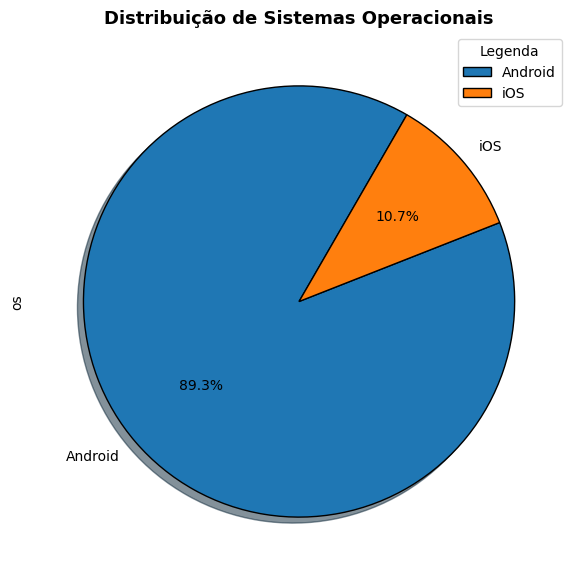

In [66]:
plt.figure(figsize=(7, 7)) 

sistemas_operacionais_distribuicao = df.groupby('os')['os'].count()


sistemas_operacionais_distribuicao.plot.pie(
    autopct='%1.1f%%',
    startangle=60,
    wedgeprops={'edgecolor':'black'},
    shadow=True
)



plt.title('Distribuição de Sistemas Operacionais', fontsize=13, fontweight='bold')

plt.legend(sistemas_operacionais_distribuicao.index, title="Legenda", loc="upper right")


plt.show()

#### "O Android domina o mercado com mais de 89% dos dispositivos<br> indicando sua forte presença."

### Qual foi o Faturamento Total em cada Mês? 

In [67]:
faturamento_mensal = (
     df.groupby('release_month')['price_usd']
     .sum()
     .reset_index()
)

print(faturamento_mensal)

# Mês com maior faturamento foi de Abril com R$ 82678 dólares

   release_month  price_usd
0          April      82678
1         August      67065
2       December      64098
3       February      72935
4        January      76899
5           July      77040
6           June      62573
7          March      63422
8            May      57124
9       November      59237
10       October      66198
11     September      64209


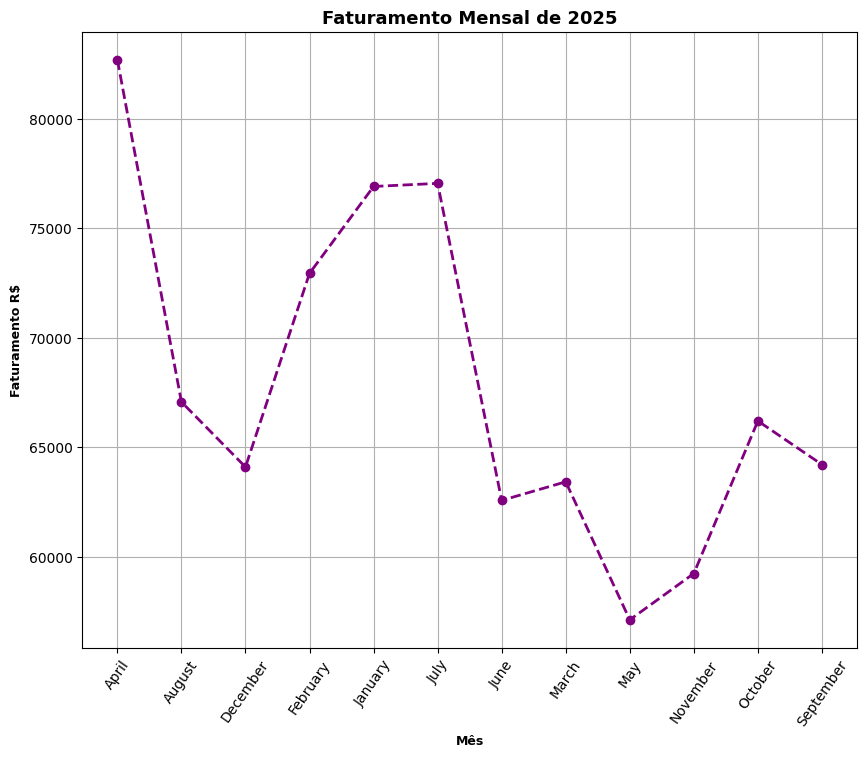

In [68]:
plt.figure(figsize=(10, 8))

plt.plot(faturamento_mensal['release_month'], faturamento_mensal['price_usd'], marker='o', linestyle='--', linewidth=2, color='purple') 

plt.title('Faturamento Mensal de 2025', fontsize=13, fontweight='bold')
plt.xlabel('Mês', fontsize=9, fontweight='bold')
plt.ylabel('Faturamento R$', fontsize=9, fontweight='bold')
plt.grid(True)
plt.xticks(rotation=55, ha='center')
plt.show()

### Quantidade de Lançamento por Mês

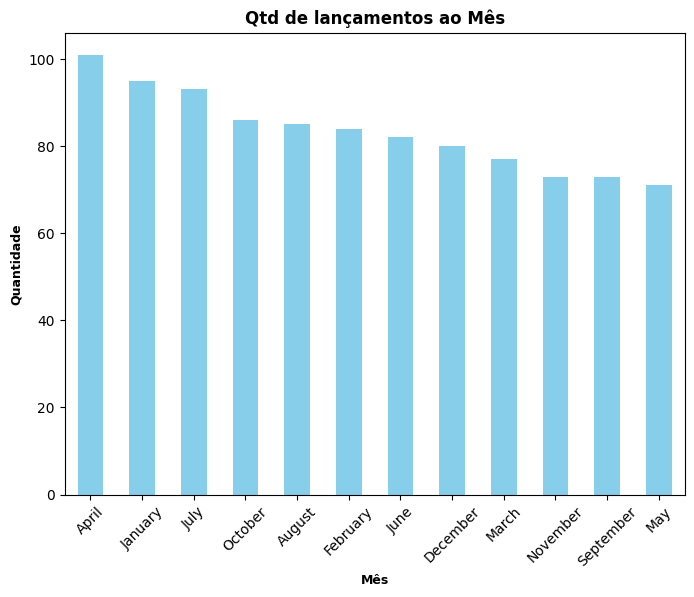

In [69]:
qtd_lancamento_mensal = df['release_month'].value_counts()


plt.figure(figsize=(8, 6))

qtd_lancamento_mensal.plot(kind='bar', color='skyblue')

plt.title('Qtd de lançamentos ao Mês', fontsize=12, fontweight='bold')
plt.xlabel('Mês', fontsize=9, fontweight='bold')
plt.ylabel('Quantidade', fontsize=9, fontweight='bold')
plt.xticks(rotation=45, ha='center')
plt.show()

##### "Mês com maior quantidade de lançamentos foi **Abril**"

### Análise de Suporte ao 5G

In [36]:
# Comparando modelos com e sem 5G

df.groupby('5g_support')[['price_usd', 'rating', 'ram_gb']].mean().round(2).rename(columns={'price_usd':'Preço em dólar', 'rating':'Avaliação Média'})


# Resultados mostram que modelos sem suporte ao 5G apresentam em média, avaliações ligeiramente superiores, apesar de custarem um pouco mais.

# Por outro lado, os smartphones com suporte a 5G, tem o maior desempenho em volume no nosso conjunto de dados analisado (503 modelos com 5G contra 497 sem 5G).

# Além disso, apresentam preço médio menor e configuração de RAM semelhante, o que reforca ainda mais o porque de liderarem em volume comparando aos sem suporte a 5G.

,Preço em dólar,Avaliação Média,ram_gb
5g_support,,,
No,821.83,4.24,9.13
Yes,805.22,4.22,9.21


In [37]:
# Quantidade vendidas com suporte e sem suporte a 5G

df['5g_support'].value_counts()


5g_support
Yes    503
No     497
Name: count, dtype: int64

## Conclusão Final

##### Android domina o mercado<br>
##### Marcas como Samsung e Realme se destacam<br>
##### Modelos com 5G lideram em volume<br>
##### Preço médio não necessariamente define melhor avaliação